In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
fake_df = pd.read_csv("../Data/Fake.csv")
true_df = pd.read_csv("../Data/True.csv")

print("Fake news:", fake_df.shape)
print("Real news:", true_df.shape)

Fake news: (23481, 4)
Real news: (21417, 4)


In [4]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
fake_df["label"] = 0
true_df["label"] = 1

In [7]:
df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

In [8]:
print("Dataset shape:", df.shape)

Dataset shape: (44898, 5)


In [9]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [10]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

In [11]:
df["label"].value_counts(normalize=True) * 100

label
0    52.298543
1    47.701457
Name: proportion, dtype: float64

In [12]:
print(df.columns.tolist())

['title', 'text', 'subject', 'date', 'label']


In [13]:
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [14]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [15]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 209


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [18]:
df.describe(include="all")

,title,text,subject,date,label
count,44898,44898,44898,44898,44898.000000
unique,38729,38646,8,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",NaN
freq,14,627,11272,182,NaN
mean,NaN,NaN,NaN,NaN,0.477015
std,NaN,NaN,NaN,NaN,0.499477
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


In [19]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", df.shape)

Before removing duplicates: (44898, 5)
After removing duplicates: (44689, 5)


In [20]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [21]:
print(df["label"].value_counts())

label
0    23478
1    21211
Name: count, dtype: int64


In [22]:
print(df["label"].value_counts(normalize=True) * 100)

label
0    52.536418
1    47.463582
Name: proportion, dtype: float64


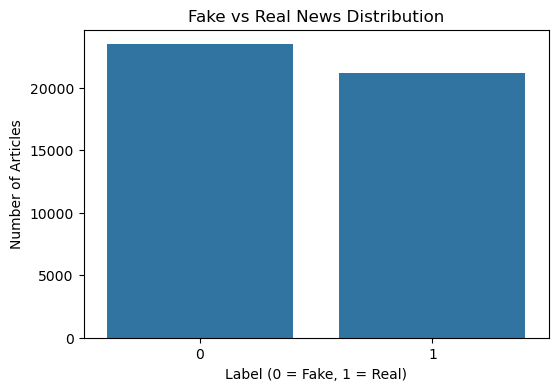

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Fake vs Real News Distribution")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Number of Articles")

plt.show()

In [24]:
label_percentage = df["label"].value_counts(normalize=True) * 100

print(label_percentage)

label
0    52.536418
1    47.463582
Name: proportion, dtype: float64


In [25]:
df["text_length"] = df["text"].fillna("").str.len()

In [26]:
df["text_length"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: text_length, dtype: float64

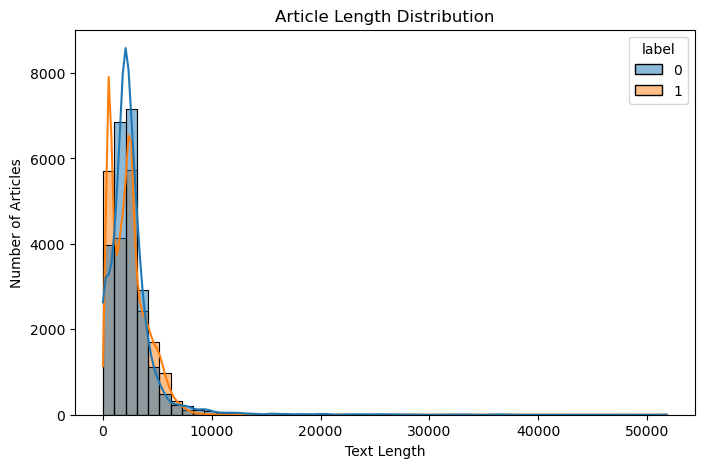

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="text_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Article Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Number of Articles")

plt.show()

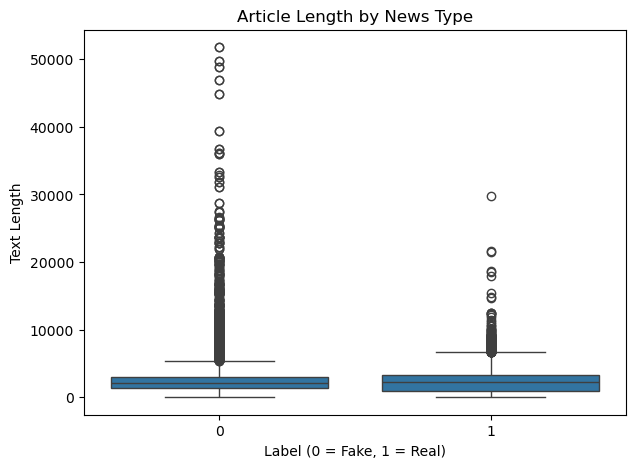

In [28]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="label",
    y="text_length"
)

plt.title("Article Length by News Type")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Text Length")

plt.show()

In [29]:
print(df["subject"].value_counts())

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


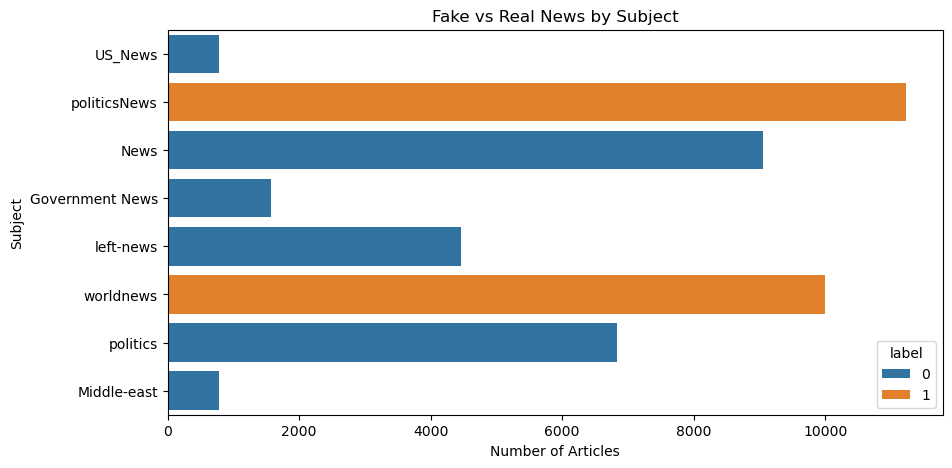

In [30]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="subject",
    hue="label"
)

plt.title("Fake vs Real News by Subject")
plt.xlabel("Number of Articles")
plt.ylabel("Subject")

plt.show()

In [31]:
print(df[["title", "text", "subject"]].isnull().sum())

title      0
text       0
subject    0
dtype: int64


In [32]:
print(df.columns.tolist())

['title', 'text', 'subject', 'date', 'label', 'text_length']


In [33]:
print("content" in df.columns)

False


In [34]:
df["content"] = (
    df["title"].fillna("") + " " +
    df["text"].fillna("")
)

In [35]:
print(df.columns.tolist())

['title', 'text', 'subject', 'date', 'label', 'text_length', 'content']


In [36]:
df[["title", "content", "label"]].head()

,title,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,Donald Trump heads for Scotland to reopen a go...,1


In [37]:
print(
    "Empty articles:",
    (df["content"].str.strip() == "").sum()
)

Empty articles: 0


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [39]:
X = df["content"]
y = df["label"]

In [40]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 35751
Testing samples: 8938


In [42]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50000
)

In [43]:
X_train_tfidf = tfidf.fit_transform(X_train_text)

In [44]:
X_test_tfidf = tfidf.transform(X_test_text)

In [45]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (35751, 50000)
Testing TF-IDF shape: (8938, 50000)


In [46]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))
print("First 20 features:")
print(feature_names[:20])

Number of features: 50000
First 20 features:
['00' '00 mark' '00 pm' '000' '000 000' '000 10' '000 according'
 '000 acres' '000 additional' '000 american' '000 americans' '000 barrels'
 '000 bond' '000 children' '000 civilians' '000 clinton' '000 day'
 '000 donations' '000 emails' '000 employees']


In [47]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr = logistic_model.predict(X_test_tfidf)
y_prob_lr = logistic_model.predict_proba(X_test_tfidf)[:, 1]

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4696
           1       0.98      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938

ROC-AUC: 0.9992810396882958


In [49]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = nb_model.predict(X_test_tfidf)
y_prob_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]

In [50]:
print("Naive Bayes")
print(classification_report(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))

Naive Bayes
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4696
           1       0.95      0.95      0.95      4242

    accuracy                           0.95      8938
   macro avg       0.95      0.95      0.95      8938
weighted avg       0.95      0.95      0.95      8938

ROC-AUC: 0.9899195961212086


In [51]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Linear SVM")
print(classification_report(y_test, y_pred_svm))

Linear SVM
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4696
           1       0.99      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



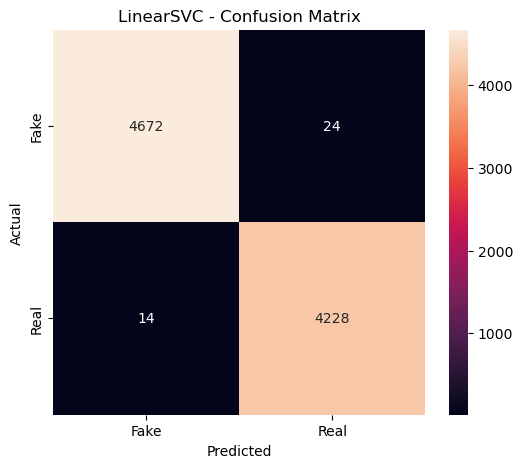

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("LinearSVC - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../results/linear_svc_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

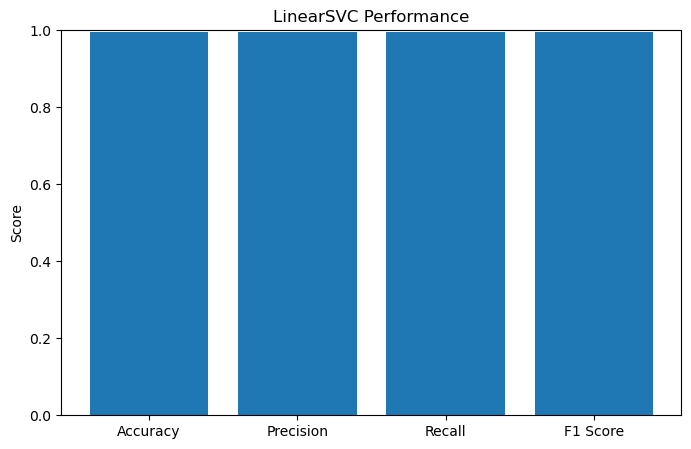

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

svm_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1 Score": f1_score(y_test, y_pred_svm)
}

plt.figure(figsize=(8, 5))

plt.bar(
    svm_metrics.keys(),
    svm_metrics.values()
)

plt.ylim(0, 1)
plt.title("LinearSVC Performance")
plt.ylabel("Score")

plt.savefig(
    "../results/linear_svc_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_xgb = xgb_model.predict(X_test_tfidf)
y_prob_xgb = xgb_model.predict_proba(X_test_tfidf)[:, 1]

In [54]:
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938

ROC-AUC: 0.9999177728675763


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Get LinearSVC decision scores
svm_scores = svm_model.decision_function(X_test_tfidf)


# Create model comparison table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_xgb)
    ]
})


# Sort by F1 Score
results = results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)


results

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.998322,0.998349,0.998114,0.998232
1,Linear SVM,0.995748,0.994356,0.996700,0.995526
2,Logistic Regression,0.987917,0.983170,0.991513,0.987324
3,Naive Bayes,0.954688,0.954083,0.950259,0.952167


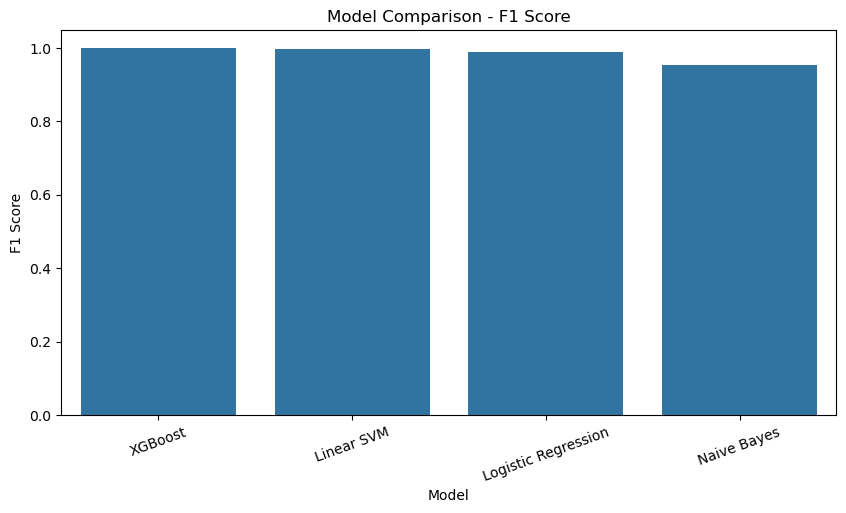

In [57]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.savefig(
    "../results/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

print("Naive Bayes ROC-AUC:",
      roc_auc_score(y_test, y_prob_nb))

print("LinearSVC ROC-AUC:",
      roc_auc_score(y_test, svm_scores))

print("XGBoost ROC-AUC:",
      roc_auc_score(y_test, y_prob_xgb))

Logistic Regression ROC-AUC: 0.9992810396882958
Naive Bayes ROC-AUC: 0.9899195961212086
LinearSVC ROC-AUC: 0.9998710369333355
XGBoost ROC-AUC: 0.9999177728675763


In [59]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [60]:
print(results.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score
            XGBoost  0.998322   0.998349 0.998114  0.998232
         Linear SVM  0.995748   0.994356 0.996700  0.995526
Logistic Regression  0.987917   0.983170 0.991513  0.987324
        Naive Bayes  0.954688   0.954083 0.950259  0.952167


In [61]:
from sklearn.metrics import classification_report, confusion_matrix

print("XGBoost Classification Report")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Fake", "Real"]
))

XGBoost Classification Report
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [62]:
cm = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4689    7]
 [   8 4234]]


In [63]:
from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.9999177728675763


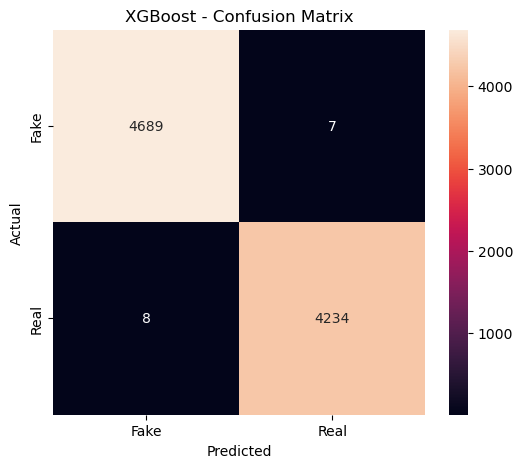

In [64]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../results/xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

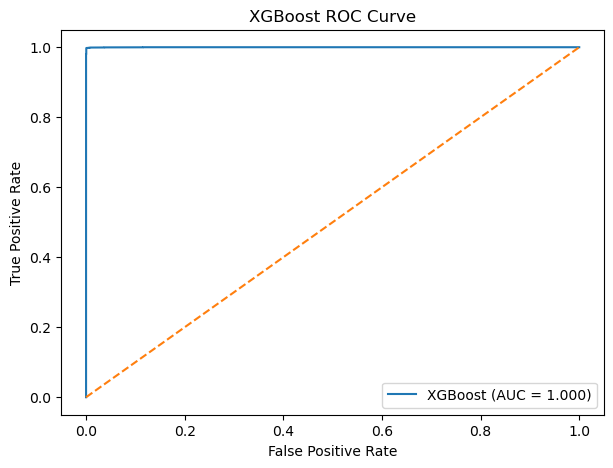

In [65]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

plt.legend()

plt.savefig(
    "../results/xgboost_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
# Check exact duplicate text between training and testing sets

train_text_set = set(
    X_train_text.str.strip().str.lower()
)

test_text_set = set(
    X_test_text.str.strip().str.lower()
)

overlap = train_text_set.intersection(test_text_set)

print("Exact text overlap:", len(overlap))

Exact text overlap: 1722


In [67]:
df["content_clean"] = (
    df["content"]
    .fillna("")
    .str.lower()
    .str.strip()
)

In [68]:
print("Duplicate contents:", df["content_clean"].duplicated().sum())

Duplicate contents: 5586


In [69]:
df = df.drop_duplicates(
    subset="content_clean"
).reset_index(drop=True)

In [70]:
print("Dataset shape after removing duplicate articles:", df.shape)
print(
    "Remaining duplicate contents:",
    df["content_clean"].duplicated().sum()
)

Dataset shape after removing duplicate articles: (39103, 8)
Remaining duplicate contents: 0


In [71]:
X = df["content"]
y = df["label"]

In [72]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
train_text_set = set(
    X_train_text
    .str.lower()
    .str.strip()
)

test_text_set = set(
    X_test_text
    .str.lower()
    .str.strip()
)

overlap = train_text_set.intersection(test_text_set)

print("Exact text overlap:", len(overlap))

Exact text overlap: 0


In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50000
)

In [75]:
X_train_tfidf = tfidf.fit_transform(X_train_text)

In [76]:
X_test_tfidf = tfidf.transform(X_test_text)

In [77]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (31282, 50000)
Testing shape: (7821, 50000)


In [78]:
pd.crosstab(
    df["subject"],
    df["label"],
    normalize="index"
).round(3)

label,0,1
subject,,
Government News,1.0,0.0
Middle-east,1.0,0.0
News,1.0,0.0
US_News,1.0,0.0
left-news,1.0,0.0
politics,1.0,0.0
politicsNews,0.0,1.0
worldnews,0.0,1.0


In [79]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr = logistic_model.predict(X_test_tfidf)
y_prob_lr = logistic_model.predict_proba(X_test_tfidf)[:, 1]

print("Logistic Regression completed.")

Logistic Regression completed.


In [80]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = nb_model.predict(X_test_tfidf)
y_prob_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]

print("Naive Bayes completed.")

Naive Bayes completed.


In [81]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("LinearSVC completed.")

LinearSVC completed.


In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm)
    ]
})

results = results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print(results.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score
         Linear SVM  0.993991   0.991327 0.997641  0.994474
Logistic Regression  0.985552   0.980662 0.992923  0.986754
        Naive Bayes  0.951285   0.959505 0.950224  0.954842


In [83]:
print(results.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score
         Linear SVM  0.993991   0.991327 0.997641  0.994474
Logistic Regression  0.985552   0.980662 0.992923  0.986754
        Naive Bayes  0.951285   0.959505 0.950224  0.954842


In [84]:
from sklearn.metrics import classification_report

print("LinearSVC - Classification Report")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Fake", "Real"]
    )
)

LinearSVC - Classification Report
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      3582
        Real       0.99      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



In [85]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print("Confusion Matrix:")
print(cm_svm)

Confusion Matrix:
[[3545   37]
 [  10 4229]]


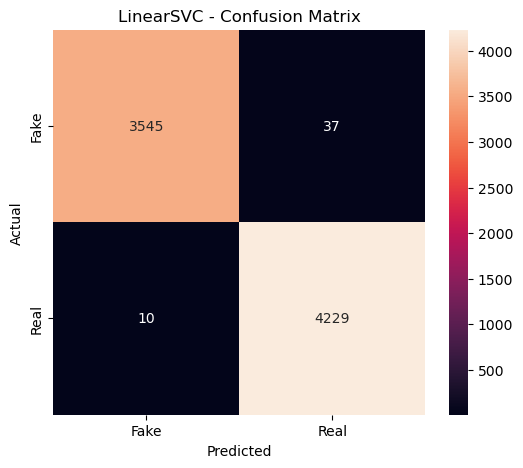

In [86]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("LinearSVC - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../results/linear_svc_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [88]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get decision scores from LinearSVC
svm_scores = svm_model.decision_function(X_test_tfidf)

print("Number of test labels:", len(y_test))
print("Number of decision scores:", len(svm_scores))

Number of test labels: 7821
Number of decision scores: 7821


In [89]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    svm_scores
)

svm_auc = roc_auc_score(
    y_test,
    svm_scores
)

print("LinearSVC ROC-AUC:", svm_auc)

LinearSVC ROC-AUC: 0.9995701423950241


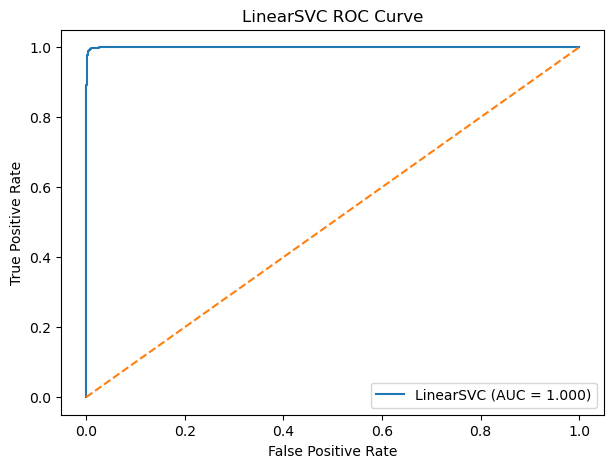

In [90]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"LinearSVC (AUC = {svm_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LinearSVC ROC Curve")

plt.legend()

plt.savefig(
    "../results/linear_svc_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save LinearSVC model
joblib.dump(
    svm_model,
    "../models/fake_news_linear_svc.pkl"
)

# Save TF-IDF vectorizer
joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

print("LinearSVC model saved successfully.")
print("TF-IDF vectorizer saved successfully.")

LinearSVC model saved successfully.
TF-IDF vectorizer saved successfully.


In [92]:
import os

print("Model exists:",
      os.path.exists("../models/fake_news_linear_svc.pkl"))

print("Vectorizer exists:",
      os.path.exists("../models/tfidf_vectorizer.pkl"))

Model exists: True
Vectorizer exists: True


In [94]:
model_size = os.path.getsize(
    "../models/fake_news_linear_svc.pkl"
)

vectorizer_size = os.path.getsize(
    "../models/tfidf_vectorizer.pkl"
)

print(f"Model size: {model_size / (1024**2):.2f} MB")
print(f"Vectorizer size: {vectorizer_size / (1024**2):.2f} MB")

Model size: 0.38 MB
Vectorizer size: 1.95 MB


In [95]:
import joblib

loaded_model = joblib.load(
    "../models/fake_news_linear_svc.pkl"
)

loaded_tfidf = joblib.load(
    "../models/tfidf_vectorizer.pkl"
)

print("Model loaded:", type(loaded_model))
print("Vectorizer loaded:", type(loaded_tfidf))

Model loaded: <class 'sklearn.svm._classes.LinearSVC'>
Vectorizer loaded: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
